In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [26]:
realizations = 5000
d = 2.0
x = 1.0
m = 2.0
e = np.random.normal(loc=0.0, scale=1.0, size=(realizations))
c = np.random.normal(loc=0.0, scale=1.0, size=(realizations))
A = c * x 
B = m * c * x + e

In [27]:
c

array([ 1.48958312, -0.7919752 , -1.07131098, ..., -0.06003983,
        0.56968054, -0.31852765], shape=(5000,))

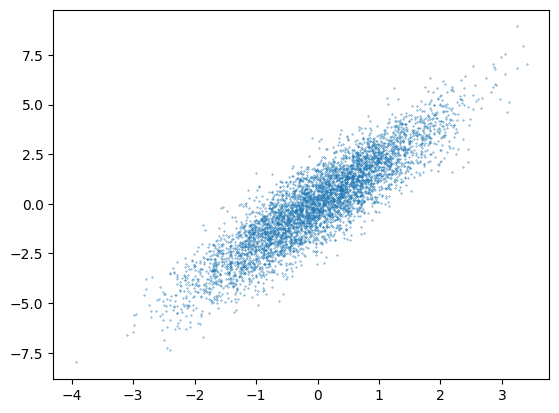

In [28]:
plt.scatter(A, B, s=0.1)
plt.show()

In [29]:
np.corrcoef(A, B)[0, 1]

np.float64(0.8951725008178266)

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

model = nn.Sequential(
    nn.Linear(1, 1),
    # nn.ReLU(),
)

class DS(Dataset):
    def __init__(self):
        self.x = torch.from_numpy(A).float().reshape(-1, 1)
        self.y = torch.from_numpy(B).float().reshape(-1, 1)
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, i):
        return self.x[i], self.y[i]

In [31]:
train_ds, test_ds, val_ds = random_split(DS(), [0.8, 0.1, 0.1])

In [32]:
def train(model, opti, loss, ds):
    model.train()
    total_loss = 0
    for x, y in ds:
        opti.zero_grad()
        pred = model(x)
        l = loss(y, pred)
        total_loss += l.item()
        l.backward()
        opti.step()
    return total_loss / len(ds)

In [33]:
def test(model, loss, ds):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in ds:
            pred = model(x)
            l = loss(y, pred)
            total_loss += l.item()
    return total_loss / len(ds)

In [34]:

batch_size = 64
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

lr = 1e-3
opti = torch.optim.Adam(model.parameters(), lr=lr)

In [35]:
import trackio

epochs = 50
loss = nn.MSELoss(reduction='mean')

trackio.init(
    project="linear-test",
    config={"epochs": epochs, "learning_rate": lr, "batch_size": batch_size}
)
for epoch in range(epochs):
    train_error = train(model, opti, loss, train_dl)
    test_error = test(model, loss, test_dl)

    trackio.log({
        "epoch": epoch,
        "train_error": train_error,
        "test_error": test_error,
    })

trackio.finish()

* Created new run: merry-cloud-10
* Run finished. Uploading logs to Trackio (please wait...)


In [36]:
val_error = test(model, loss, val_dl)

In [37]:
val_error

0.8918175399303436

In [38]:
def plot_preds(model, ds, amount):
    model.eval()
    
    with torch.no_grad():
        xx = ds.x[:amount]
        x = xx.numpy().ravel()
        y = ds.y[:amount].numpy().ravel()
        p = model(xx).detach().numpy().ravel()
        plt.scatter(x, y, s=3, label="data")
        plt.scatter(x, p, s=3, label="pred")
        plt.legend()
        plt.plot()
            

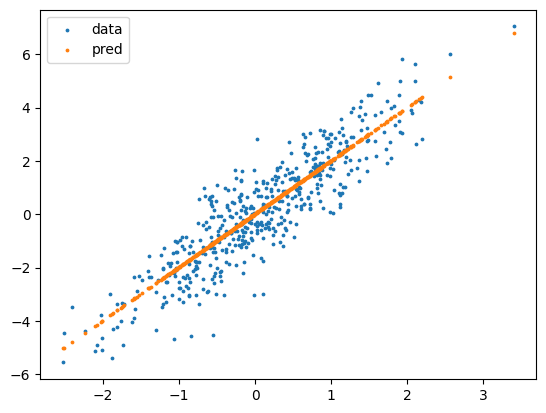

In [45]:
plot_preds(model, val_ds.dataset, 500)


In [40]:
print(A.min(), A.mean(), A.max())
print(B.min(), B.mean(), B.max())

-3.932339930701309 -0.0014054652578990386 3.40241572804272
-7.99177839012056 0.012509668489630471 8.931882020953278


In [41]:
print(B.std(), B.var())

2.231113849027529 4.977869007322435


In [42]:
R2 = 1 - val_error / B.var()

In [43]:
R2

np.float64(0.8208435098194665)

In [46]:
# context specific SNR
rho2 = np.corrcoef(A, B)[0, 1] ** 2
B_snr = rho2 / ( 1 - rho2)

In [47]:
B_snr

np.float64(4.0335690284055525)